<a href="https://colab.research.google.com/github/ifekolade/Ife-Kolade-Health-Tech-Stock-Picker/blob/main/Health_Tech_Singular_Stock_Tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Health Teck Stock Tracker

Welcome to the **Health Tech Stock Tracker**! This notebook provides an analysis of some health technology stocks in the US, including  multiple financial strategies and models.

In [1]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ticker = 'ISRG'
start_date = datetime.date (2025, 7, 3)
end_date = datetime.date (2026, 7, 3)

In [3]:
data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
type(data)
data.head(20)
data.shape

[*********************100%***********************]  1 of 1 completed


(251, 5)

In [4]:
data.dropna()
data.drop_duplicates()

Price,Close,High,Low,Open,Volume
Ticker,ISRG,ISRG,ISRG,ISRG,ISRG
Date,,,,,
2025-07-03,544.469971,547.000000,542.390015,543.929993,704800
2025-07-07,534.710022,544.880005,532.880005,543.229980,1191600
2025-07-08,527.299988,539.590027,525.669983,534.000000,1608700
2025-07-09,528.130005,530.710022,523.159973,529.820007,1380900
2025-07-10,526.049988,528.549988,520.250000,527.099976,1424600
...,...,...,...,...,...
2026-06-26,404.700012,409.779999,399.290009,399.480011,3413200
2026-06-29,405.970001,415.989990,405.140015,409.679993,2328700


In [5]:
type(data)
data.head(20)

Price,Close,High,Low,Open,Volume
Ticker,ISRG,ISRG,ISRG,ISRG,ISRG
Date,,,,,
2025-07-03,544.469971,547.000000,542.390015,543.929993,704800
2025-07-07,534.710022,544.880005,532.880005,543.229980,1191600
2025-07-08,527.299988,539.590027,525.669983,534.000000,1608700
2025-07-09,528.130005,530.710022,523.159973,529.820007,1380900
2025-07-10,526.049988,528.549988,520.250000,527.099976,1424600
2025-07-11,512.059998,522.869995,508.130005,522.869995,2951300
2025-07-14,516.440002,522.099976,509.880005,509.880005,2082700
2025-07-15,512.229980,521.280029,510.839996,519.210022,1674300


In [6]:
data.shape


(251, 5)

Visualization of ISRG Stock Price

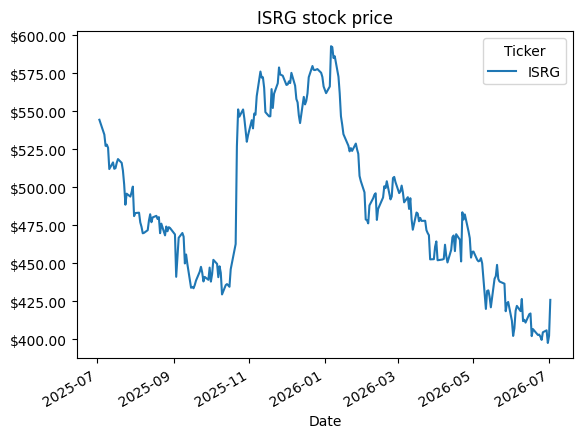

In [7]:
import matplotlib.ticker as mticker

ax = data['Close'].plot(title='ISRG stock price')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%1.2f'))
plt.show()

In [8]:
average_close_price = data['Close'].mean()
print(f"The average 'Close' price is: ${average_close_price.item():.2f}")

The average 'Close' price is: $487.97


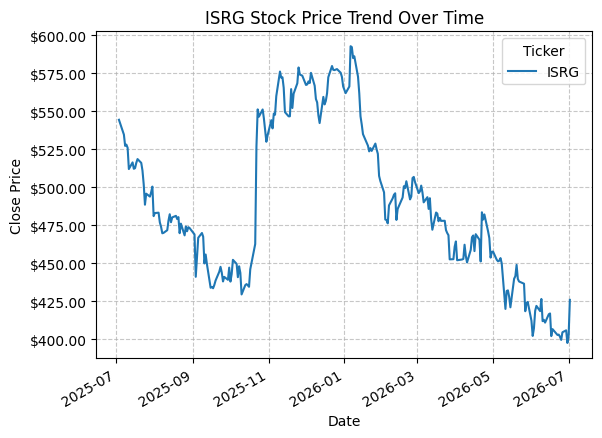

In [9]:
import matplotlib.ticker as mticker

ax = data['Close'].plot(title='ISRG Stock Price Trend Over Time')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%1.2f'))
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [10]:
import plotly.express as px

df_plot = data.copy()

df_plot.columns = df_plot.columns.get_level_values(0)

df_plot = df_plot.reset_index()

fig = px.line(df_plot, x='Date', y='Close', title='ISRG Stock Price Trend Over Time (Interactive)')
fig.update_yaxes(tickprefix='$')
fig.show()

Moving Averages

In [11]:
data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data['Signal'] = np.where(data['MA10'] > data['MA50'], 1, 0)
data['Position'] = data['Signal'].diff()

In [12]:
data['Position'].unique()

array([nan,  0.,  1., -1.])

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-07-03 to 2026-07-02
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ISRG)   251 non-null    float64
 1   (High, ISRG)    251 non-null    float64
 2   (Low, ISRG)     251 non-null    float64
 3   (Open, ISRG)    251 non-null    float64
 4   (Volume, ISRG)  251 non-null    int64  
 5   (MA10, )        242 non-null    float64
 6   (MA50, )        202 non-null    float64
 7   (Signal, )      251 non-null    int64  
 8   (Position, )    250 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 19.6 KB


/tmp/ipykernel_6058/2787702220.py:19: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



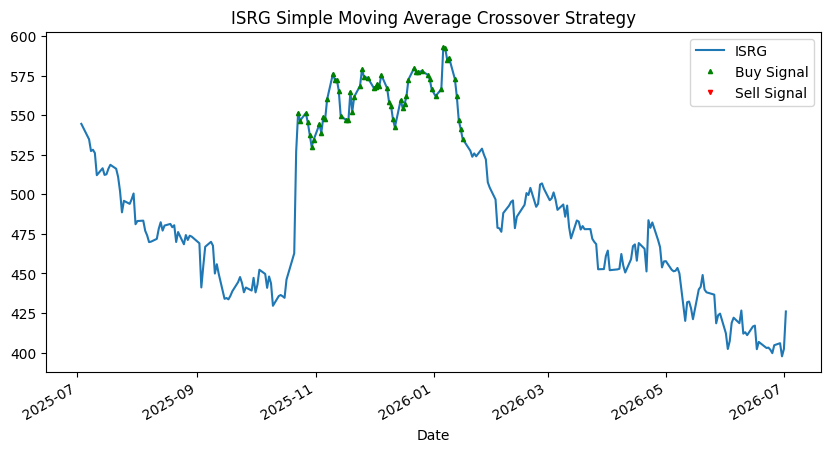

In [14]:
import pandas as pd


current_ticker = data.columns.get_level_values(1).unique()[0]

close_prices_series = data['Close'][current_ticker]
data['MA10'] = close_prices_series.rolling(window=10).mean()
data['MA50'] = close_prices_series.rolling(window=50).mean()



data['Signal'] = np.where(data['MA10'] > data['MA50'], 1, 0)
data['Position'] = data['Signal'].diff()

plt.figure(figsize=(10,5))

data_close_for_plot = data['Close'][current_ticker]
data_close_for_plot.plot(title=f'{current_ticker} Simple Moving Average Crossover Strategy')
plt.plot(data[data['Signal'] == 1].index, data_close_for_plot[data['Signal'] == 1], '^', markersize=3, color='g', label='Buy Signal')
plt.plot(data[data['Signal'] == -1].index, data_close_for_plot[data['Signal'] == -1], 'v', markersize=3, color='r', label='Sell Signal')
plt.legend()
plt.show()

# Exponential Moving Average

In [15]:
data['EMA10'] = data['Close'].ewm(span=10, adjust=False).mean()
data['EMA50'] = data['Close'].ewm(span=50, adjust=False).mean()
data['Signal'] = np.where(data['EMA10'] > data['EMA50'], 1, 0)
data['Position'] = data['Signal'].diff()

In [16]:
data['Position'].unique()

array([nan,  0.,  1., -1.])

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-07-03 to 2026-07-02
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, ISRG)   251 non-null    float64
 1   (High, ISRG)    251 non-null    float64
 2   (Low, ISRG)     251 non-null    float64
 3   (Open, ISRG)    251 non-null    float64
 4   (Volume, ISRG)  251 non-null    int64  
 5   (MA10, )        242 non-null    float64
 6   (MA50, )        202 non-null    float64
 7   (Signal, )      251 non-null    int64  
 8   (Position, )    250 non-null    float64
 9   (EMA10, )       251 non-null    float64
 10  (EMA50, )       251 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 23.5 KB


/tmp/ipykernel_6058/2433061367.py:37: UserWarning:

This axis already has a converter set and is updating to a potentially incompatible converter



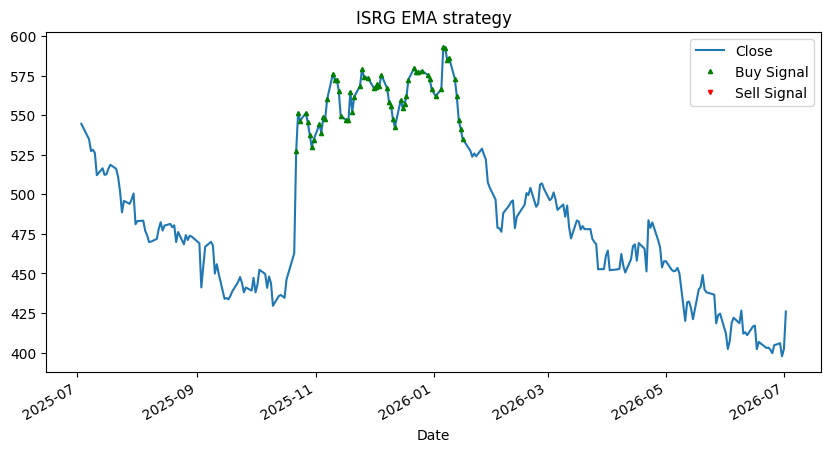

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import numpy as np


ema_plot_data_raw = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)


if isinstance(ema_plot_data_raw.columns, pd.MultiIndex):

    if ('Close', ticker) in ema_plot_data_raw.columns:
        ema_plot_data = pd.DataFrame(ema_plot_data_raw[('Close', ticker)])
        ema_plot_data.columns = ['Close']
    elif 'Close' in ema_plot_data_raw.columns:
        ema_plot_data = pd.DataFrame(ema_plot_data_raw['Close'])
        ema_plot_data.columns = ['Close']
    else:
        raise KeyError(f"Could not find a 'Close' column for ticker {ticker} in downloaded data.")
else:

    if 'Close' in ema_plot_data_raw.columns:
        ema_plot_data = ema_plot_data_raw[['Close']].copy()
    else:
        raise KeyError(f"Could not find a 'Close' column for ticker {ticker} in downloaded data.")


ema_plot_data['EMA10'] = ema_plot_data['Close'].ewm(span=10, adjust=False).mean()
ema_plot_data['EMA50'] = ema_plot_data['Close'].ewm(span=50, adjust=False).mean()
ema_plot_data['Signal'] = np.where(ema_plot_data['EMA10'] > ema_plot_data['EMA50'], 1, 0)
ema_plot_data['Position'] = ema_plot_data['Signal'].diff()

current_ticker_value = ticker

plt.figure(figsize=(10,5))
ema_plot_data['Close'].plot(title=f'{current_ticker_value} EMA strategy')
plt.plot(ema_plot_data[ema_plot_data['Signal']==1].index, ema_plot_data['Close'][ema_plot_data['Signal']==1], '^', markersize=3, color = 'g', label='Buy Signal')
plt.plot(ema_plot_data[ema_plot_data['Signal']== -1].index, ema_plot_data['Close'][ema_plot_data['Signal']== -1], 'v', markersize=3, color = 'r', label='Sell Signal')

plt.legend()
plt.show()

# Backtesting

In [19]:
portfolio = pd.DataFrame(index=data.index)
portfolio['Position'] = data['Position']
if 'Adj Close' not in data.columns:
    data['Adj Close'] = data['Close']
portfolio['Adj Close'] = data['Adj Close']
portfolio['Position'] = data['Position']
portfolio['Holdings'] = (data['Position'].cumsum() * data['Adj Close']).fillna(0)
initial_cash = 100000
portfolio['Cash'] = initial_cash - (data['Adj Close'] * data['Position']).cumsum()
portfolio['Total'] = portfolio['Holdings'] + portfolio['Cash']
portfolio['Returns'] = portfolio['Total'].pct_change().fillna(0)
portfolio.tail(50)

,Position,Adj Close,Holdings,Cash,Total,Returns
Date,,,,,,
2026-04-22,0.0,483.619995,0.0,100000.409973,100000.409973,0.0
2026-04-23,0.0,478.820007,0.0,100000.409973,100000.409973,0.0
2026-04-24,0.0,482.220001,0.0,100000.409973,100000.409973,0.0
2026-04-27,0.0,470.989990,0.0,100000.409973,100000.409973,0.0
2026-04-28,0.0,466.640015,0.0,100000.409973,100000.409973,0.0
2026-04-29,0.0,453.829987,0.0,100000.409973,100000.409973,0.0
2026-04-30,0.0,457.609985,0.0,100000.409973,100000.409973,0.0
2026-05-01,0.0,457.779999,0.0,100000.409973,100000.409973,0.0
2026-05-04,0.0,452.350006,0.0,100000.409973,100000.409973,0.0


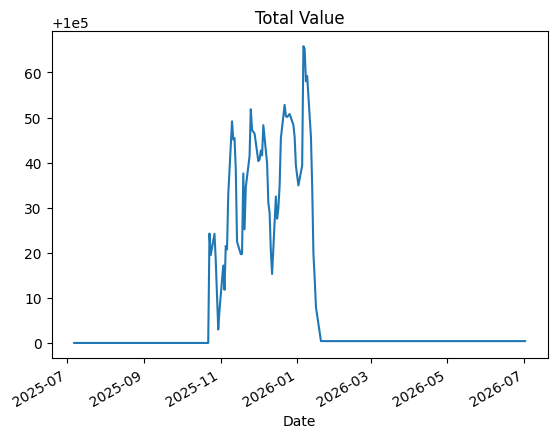

In [20]:
initial_capital = 100000
portfolio['Cash'] = initial_capital - (data['Adj Close'] * data['Position']).cumsum()
portfolio['Total'] = portfolio['Holdings'] + portfolio['Cash']

portfolio['Total'].plot(title='Total Value')
plt.show()

Comparing Models

In [21]:
data['Returns'] = data['Close', 'ISRG'].pct_change()
data['MA10'] = data['Close', 'ISRG'].rolling(window=10).mean()
data['MA50'] = data['Close', 'ISRG'].rolling(window=50).mean()
data.head(10)

Price,Close,High,Low,Open,Volume,MA10,MA50,Signal,Position,EMA10,EMA50,Adj Close,Returns
Ticker,ISRG,ISRG,ISRG,ISRG,ISRG,,,,,,,,
Date,,,,,,,,,,,,,
2025-07-03,544.469971,547.000000,542.390015,543.929993,704800,NaN,NaN,0,NaN,544.469971,544.469971,544.469971,NaN
2025-07-07,534.710022,544.880005,532.880005,543.229980,1191600,NaN,NaN,0,0.0,542.695435,544.087228,534.710022,-0.017926
2025-07-08,527.299988,539.590027,525.669983,534.000000,1608700,NaN,NaN,0,0.0,539.896262,543.428904,527.299988,-0.013858
2025-07-09,528.130005,530.710022,523.159973,529.820007,1380900,NaN,NaN,0,0.0,537.756943,542.828948,528.130005,0.001574
2025-07-10,526.049988,528.549988,520.250000,527.099976,1424600,NaN,NaN,0,0.0,535.628406,542.170949,526.049988,-0.003938
2025-07-11,512.059998,522.869995,508.130005,522.869995,2951300,NaN,NaN,0,0.0,531.343240,540.990128,512.059998,-0.026594
2025-07-14,516.440002,522.099976,509.880005,509.880005,2082700,NaN,NaN,0,0.0,528.633561,540.027378,516.440002,0.008554
2025-07-15,512.229980,521.280029,510.839996,519.210022,1674300,NaN,NaN,0,0.0,525.651092,538.937284,512.229980,-0.008152


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

ml_data = yf.download('ISRG', start='2020-03-13', end='2025-11-30', auto_adjust=True)
ml_data['Returns'] = ml_data['Close'].pct_change()
ml_data['MA10'] = ml_data['Close'].rolling(window=10).mean()
ml_data['MA50'] = ml_data['Close'].rolling(window=50).mean()
ml_data['Target'] = (ml_data['Returns'].shift(-1) > 0).astype(int)
ml_data.dropna(inplace=True)

X = ml_data[['Returns', 'MA10', 'MA50']]
y = ml_data['Target']

[*********************100%***********************]  1 of 1 completed


In [23]:
data.head(10)

Price,Close,High,Low,Open,Volume,MA10,MA50,Signal,Position,EMA10,EMA50,Adj Close,Returns
Ticker,ISRG,ISRG,ISRG,ISRG,ISRG,,,,,,,,
Date,,,,,,,,,,,,,
2025-07-03,544.469971,547.000000,542.390015,543.929993,704800,NaN,NaN,0,NaN,544.469971,544.469971,544.469971,NaN
2025-07-07,534.710022,544.880005,532.880005,543.229980,1191600,NaN,NaN,0,0.0,542.695435,544.087228,534.710022,-0.017926
2025-07-08,527.299988,539.590027,525.669983,534.000000,1608700,NaN,NaN,0,0.0,539.896262,543.428904,527.299988,-0.013858
2025-07-09,528.130005,530.710022,523.159973,529.820007,1380900,NaN,NaN,0,0.0,537.756943,542.828948,528.130005,0.001574
2025-07-10,526.049988,528.549988,520.250000,527.099976,1424600,NaN,NaN,0,0.0,535.628406,542.170949,526.049988,-0.003938
2025-07-11,512.059998,522.869995,508.130005,522.869995,2951300,NaN,NaN,0,0.0,531.343240,540.990128,512.059998,-0.026594
2025-07-14,516.440002,522.099976,509.880005,509.880005,2082700,NaN,NaN,0,0.0,528.633561,540.027378,516.440002,0.008554
2025-07-15,512.229980,521.280029,510.839996,519.210022,1674300,NaN,NaN,0,0.0,525.651092,538.937284,512.229980,-0.008152


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5, random_state=42)

rf = RandomForestClassifier(random_state=42)
log_reg = LogisticRegression()
svm = SVC()

models = [rf, log_reg, svm]

for model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{model.__class__.__name__} Accuracy: {accuracy}")


RandomForestClassifier Accuracy: 0.5230547550432276
LogisticRegression Accuracy: 0.5489913544668588
SVC Accuracy: 0.5489913544668588


# Performance Metrics and Model Evaluation

In [25]:
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

data = yf.download('ISRG', start='2020-03-13', end='2025-11-30', auto_adjust=True)
data['Returns'] = data['Close'].pct_change()
data['MA10'] = data['Close'].rolling(window=10).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()
data['Target'] = (data['Returns'].shift(-1) > 0).astype(int)
data.dropna(inplace=True)

X = data[['Returns', 'MA10', 'MA50']]
y = data['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5, random_state=42)

rf = RandomForestClassifier(random_state=42)
log_reg = LogisticRegression()
svm = SVC()

models = [rf, log_reg, svm]

for model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    conf_matrix = confusion_matrix(y_test, predictions);


    conf_matrix_df = pd.DataFrame(conf_matrix,
                                  index=['Actual: Price Down (0)', 'Actual: Price Up (1)'],
                                  columns=['Predicted: Price Down (0)', 'Predicted: Price Up (1)'])
    print(f"\nConfusion Matrix for {model.__class__.__name__}:")
    print(conf_matrix_df)

    report = classification_report(y_test, predictions, zero_division=0)
    print(f"\nClassification Report for {model.__class__.__name__}:")
    print(report)

[*********************100%***********************]  1 of 1 completed



Confusion Matrix for RandomForestClassifier:
                        Predicted: Price Down (0)  Predicted: Price Up (1)
Actual: Price Down (0)                        147                      166
Actual: Price Up (1)                          165                      216

Classification Report for RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47       313
           1       0.57      0.57      0.57       381

    accuracy                           0.52       694
   macro avg       0.52      0.52      0.52       694
weighted avg       0.52      0.52      0.52       694


Confusion Matrix for LogisticRegression:
                        Predicted: Price Down (0)  Predicted: Price Up (1)
Actual: Price Down (0)                          0                      313
Actual: Price Up (1)                            0                      381

Classification Report for LogisticRegression:
              precision    recall  f1

# Visualization

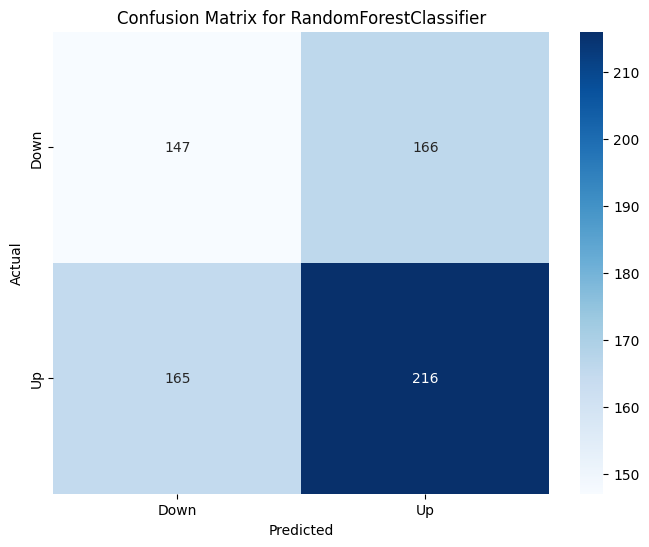

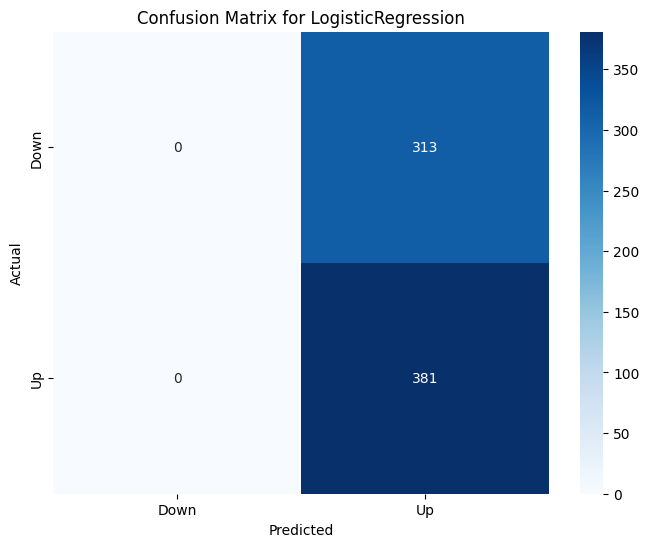

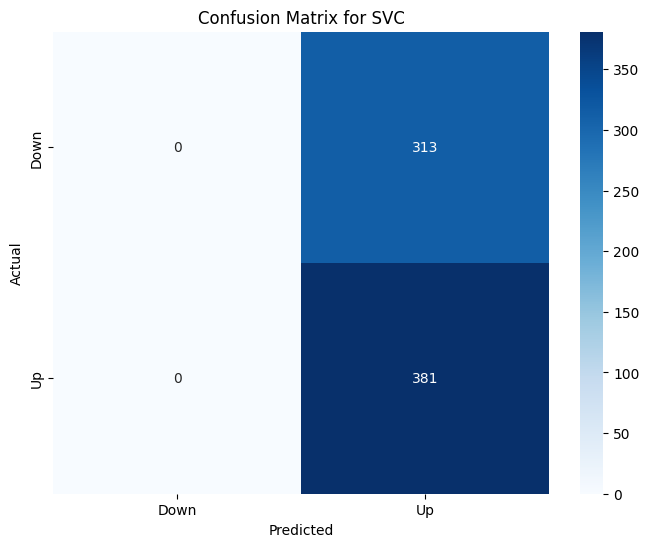

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for model in models:
    predictions = model.predict(X_test)
    conf_matrix = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
    plt.title(f'Confusion Matrix for {model.__class__.__name__}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Capital Asset Pricing Model (CAPM) Parameter Estimation

In [27]:
import yfinance as yf
import pandas as pd
import statsmodels.api as sm

In [28]:
tickers = ['ISRG', 'JNJ', 'LLY', '^GSPC']
data = yf.download(tickers, period='1y', interval='1d', auto_adjust=True)['Close']

data = data.rename(columns={'^GSPC': 'SP500'})

[*********************100%***********************]  4 of 4 completed


In [29]:
returns = data.pct_change().dropna()
returns.head(10)

Ticker,ISRG,JNJ,LLY,SP500
Date,,,,
2025-07-07,-0.017926,-0.004743,-0.009991,-0.007862
2025-07-08,-0.013858,0.003349,0.006198,-0.000716
2025-07-09,0.001574,0.003145,0.011908,0.006062
2025-07-10,-0.003938,0.009022,0.004740,0.002746
2025-07-11,-0.026594,-0.005010,0.002985,-0.003298
2025-07-14,0.008554,-0.000510,0.007982,0.001407
2025-07-15,-0.008152,-0.010522,-0.034516,-0.003956
2025-07-16,0.000800,0.061932,0.023388,0.003194
2025-07-17,0.006866,-0.010924,-0.035832,0.005374


In [30]:
rf_annual = 0.04
rf_daily = (1+rf_annual)**(1/365) - 1
returns['RF'] = rf_daily

In [31]:
excess = pd.DataFrame({
    'SP500_exc': returns['SP500'] - returns['RF'],
})
for stock in ['ISRG', 'JNJ', 'LLY']:
    excess[f'{stock}_exc'] = returns[stock] - returns['RF']

excess.head(10)

,SP500_exc,ISRG_exc,JNJ_exc,LLY_exc
Date,,,,
2025-07-07,-0.007970,-0.018033,-0.004851,-0.010099
2025-07-08,-0.000823,-0.013966,0.003241,0.006090
2025-07-09,0.005955,0.001467,0.003038,0.011800
2025-07-10,0.002639,-0.004046,0.008915,0.004633
2025-07-11,-0.003405,-0.026702,-0.005117,0.002877
2025-07-14,0.001300,0.008446,-0.000617,0.007875
2025-07-15,-0.004064,-0.008259,-0.010629,-0.034623
2025-07-16,0.003086,0.000693,0.061824,0.023281
2025-07-17,0.005266,0.006759,-0.011031,-0.035939


In [32]:
def run_capm(y_exc, x_exc):

    X = sm.add_constant(x_exc)
    model = sm.OLS(y_exc, X).fit()
    return model

In [33]:
results = {}

for stock in ['ISRG', 'JNJ', 'LLY']:
    y_exc = excess[f'{stock}_exc']
    x_exc = excess['SP500_exc']
    model = run_capm(y_exc, x_exc)
    results[stock] = {
        'alpha': model.params['const'],
        'beta' : model.params['SP500_exc'],
        'R2'   : model.rsquared,
    }

pd.DataFrame(results).T.rename_axis('Ticker').round(4)

,alpha,beta,R2
Ticker,,,
ISRG,-0.0014,0.8499,0.1154
JNJ,0.0022,-0.0802,0.0030
LLY,0.0017,0.4938,0.0257


# Building Efficient Frontier

In [34]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [46]:
tickers = ["ISRG", "JNJ", "LLY"]
start_date = "2023-11-30"
end_date   = "2025-11-30"

In [36]:
raw_data = yf.download(tickers, start=start_date, end=end_date, progress=True, auto_adjust=True)

[*********************100%***********************]  3 of 3 completed


In [37]:
prices = raw_data['Close'].copy()

In [38]:
print(prices.head(10))

Ticker            ISRG         JNJ         LLY
Date                                          
2023-11-30  310.839996  143.864624  580.888794
2023-12-01  315.200012  147.324982  574.009155
2023-12-04  311.839996  147.790070  575.620911
2023-12-05  309.519989  147.483109  578.048523
2023-12-06  310.260010  145.687836  579.129639
2023-12-07  311.559998  144.552963  578.166504
2023-12-08  310.420013  143.641373  587.778381
2023-12-11  315.429993  144.236694  574.009155
2023-12-12  320.709991  144.246017  574.716858
2023-12-13  328.959991  144.915771  587.237915


In [39]:
returns = prices.pct_change().dropna()

In [40]:
mean_daily_returns = returns.mean()
mean_daily_returns

,0
Ticker,
ISRG,0.001422
JNJ,0.000765
LLY,0.001480


In [41]:
cov_matrix_daily = returns.cov()
print(cov_matrix_daily)

Ticker      ISRG       JNJ       LLY
Ticker                              
ISRG    0.000402  0.000004  0.000133
JNJ     0.000004  0.000120  0.000037
LLY     0.000133  0.000037  0.000506


In [42]:
corr_matrix_daily = returns.corr()
print(corr_matrix_daily)

Ticker      ISRG       JNJ       LLY
Ticker                              
ISRG    1.000000  0.016356  0.295288
JNJ     0.016356  1.000000  0.149001
LLY     0.295288  0.149001  1.000000


In [43]:
trading_days = 252
mean_annual_returns = mean_daily_returns*trading_days
print(mean_annual_returns)
cov_matrix_annual = cov_matrix_daily * trading_days
print(cov_matrix_annual)


volatility_annual = returns.std() * np.sqrt(trading_days)

Ticker
ISRG    0.358462
JNJ     0.192774
LLY     0.372875
dtype: float64
Ticker      ISRG       JNJ       LLY
Ticker                              
ISRG    0.101415  0.000905  0.033576
JNJ     0.000905  0.030197  0.009245
LLY     0.033576  0.009245  0.127487


In [47]:
import statsmodels.api as sm
import yfinance as yf
import pandas as pd


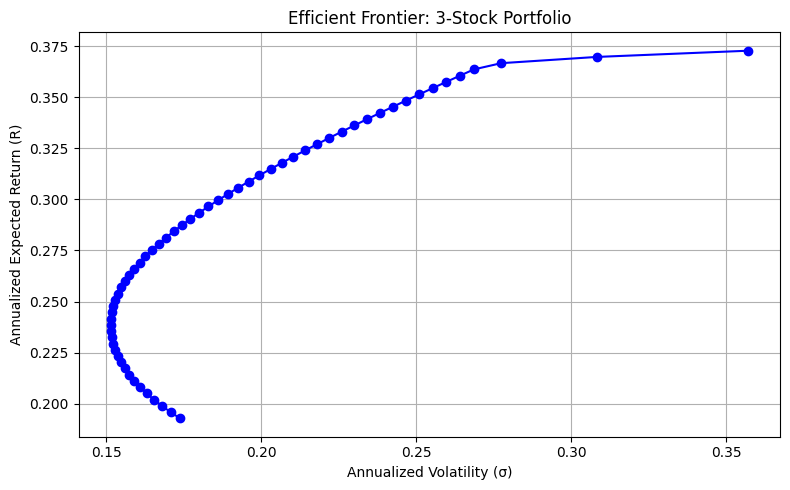

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf


def efficient_frontier(mu, Sigma, n_points=100):
    """
    mu : array of expected returns of the stocks
    Sigma : covariance matrix of the stocks
    Compute a long-only efficient frontier:
      - minimize portfolio volatility σ = sqrt(wᵀ Σ w)
      - subject to: sum(w) = 1, wᵀ mu = R_target, and 0 ≤ w_i ≤ 1
    Returns:
      vols      : array of volatilities (σ) along the frontier
      rets      : matching target returns (R_target)
      weights   : list of optimal weight vectors for each point
    """
    n = len(mu)
    vols, rets, weights = [], [], []


    R_targets = np.linspace(mu.min(), mu.max(), n_points)

    for R in R_targets:

        objective = lambda w: np.sqrt(w @ Sigma @ w)

        cons = (
            {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
            {"type": "eq", "fun": lambda w: w @ mu - R}
        )

        bounds = [(0.0, 1.0)] * n

        w0 = np.repeat(1/n, n)

        result = minimize(objective, w0, bounds=bounds, constraints=cons)
        if result.success:
            vols.append(result.fun)
            rets.append(R)
            weights.append(result.x)

    return np.array(vols), np.array(rets), weights



raw_data_ef = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)
prices_ef = raw_data_ef['Close'].copy()
returns_ef = prices_ef.pct_change().dropna()


trading_days = 252
mu_annual    = returns_ef.mean() * trading_days
Sigma_annual = returns_ef.cov() * trading_days

tickers_for_ef = [t for t in tickers if t != '^GSPC']
mu_vec    = mu_annual.loc[tickers_for_ef].values
Sigma_sub = Sigma_annual.loc[tickers_for_ef, tickers_for_ef].values


vols5, rets5, weights5 = efficient_frontier(mu_vec, Sigma_sub, n_points=60)


plt.figure(figsize=(8, 5))
plt.plot(vols5, rets5, marker='o', linestyle='-', color='blue')
plt.title(f"Efficient Frontier: {len(tickers_for_ef)}-Stock Portfolio")
plt.xlabel("Annualized Volatility (σ)")
plt.ylabel("Annualized Expected Return (R)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
idx_min = np.argmin(vols5)

min_risk_weights = weights5[idx_min]

print("Lowest risk (σ):", vols5[idx_min])
print("Expected return at lowest risk (R):", rets5[idx_min])

for i, ticker in enumerate(tickers_for_ef):
    weight = min_risk_weights[i]
    print(f"{ticker}: {weight:.3%}")

Lowest risk (σ): 0.15138483987509796
Expected return at lowest risk (R): 0.238562437950679
ISRG: 19.430%
JNJ: 73.021%
LLY: 7.548%


# Mean Reversion Strategy (Long Only)

In [50]:
import datetime
import yfinance as yf
import pandas as pd

initial_capital = 10_000.00
ticker          = "ISRG"
end_date        = "2025-11-30"
start_date      = "2024-11-30"

data   = yf.download(ticker, start=start_date, end=end_date, progress=False, auto_adjust=True)


if isinstance(data.columns, pd.MultiIndex):

    prices = data[('Close', ticker)].dropna()
else:

    prices = data['Close'].dropna()
prices

,Close
,ISRG
Date,
2024-12-02,542.849976
2024-12-03,541.710022
2024-12-04,549.950012
2024-12-05,547.650024
2024-12-06,550.409973
...,...
2025-11-21,561.609985
2025-11-24,568.479980


In [51]:
import numpy as np
import pandas as pd


delta = prices.diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

N = 14
avg_gain = gain.rolling(window=N).mean()
avg_loss = loss.rolling(window=N).mean()

rs  = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

signal = pd.Series(0, index=prices.index, dtype=int)
signal.loc[rsi < 30] = 1
signal.loc[rsi > 70] = -1

positions = signal.replace(-1, 0)


positions = positions.ffill()

positions = positions.shift(1).fillna(0)

In [52]:

returns = prices.pct_change().fillna(0)

strat_rets   = positions * returns

equity_curve = initial_capital * (1 + strat_rets).cumprod()

In [53]:

final_amount = equity_curve.iloc[-1]
net_profit   = final_amount - initial_capital

print(f"Initial Capital : ${initial_capital:,.2f}")
print(f"Final Amount    : ${final_amount:,.2f}")
print(f"Net Profit      : ${net_profit:,.2f}")



Initial Capital : $10,000.00
Final Amount    : $10,220.41
Net Profit      : $220.41
